# Local neurotransmitter fingerprinting

In this tutorial, you will explore the local neurotransmitter fingerprinting (LNTF) functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch the neurotransmitter PET atlas
- Compute per-target neurotransmitter density scores within a lesion
- Filter by neurotransmitter system presets
- Obtain parcel-level NT scores

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/06-local-neurotransmitter-fingerprinting.ipynb)

## Colab

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

Ignore this if you run this notebook locally.

## Setup

In [ ]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

Get the tutorial data.

In [1]:
# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids --force


Setting up tutorial data at: /tmp/tutorial_bids
✓ Tutorial data copied to: /tmp/tutorial_bids


## Fetch neurotransmitter atlas

Local neurotransmitter fingerprinting requires a neurotransmitter PET atlas: a collection of PET receptor/transporter density maps from normative cohorts. Lacuna downloads representative maps from the data repository of [NiSpace](https://github.com/LeonDLotter/NiSpace-data).

`lacuna fetch ntatlas` downloads, z-scores, and saves a ready-to-use atlas in a single step. The output directory contains the prepared atlas and is consumed directly by `lacuna run lntf`.

*Note on the cerebellum:* in most PET maps the cerebellum (or a cerebellar grey-matter sub-region) is used as a reference region and is masked out. Expect zero / NaN values for cerebellar lesions.

In [7]:
!lacuna fetch ntatlas \
    --output-dir /tmp/ntatlas_data --force

Fetching neurotransmitter PET maps...
  Source: https://github.com/LeonDLotter/NiSpace-data
  Commit: a772c410f76dbbd022a3f5239e40176ff6f930c7


✓ Neurotransmitter atlas fetch complete!
  Files: 22
  Duration: 2.3s
  Output: /tmp/ntatlas_data


In [9]:
!ls /tmp/ntatlas_data/maps

5HT1a.nii.gz  5HTT.nii.gz  DAT.nii.gz	  KOR.nii.gz	 NMDA.nii.gz
5HT1b.nii.gz  A4B2.nii.gz  FDOPA.nii.gz   M1.nii.gz	 VAChT.nii.gz
5HT2a.nii.gz  CB1.nii.gz   GABAa5.nii.gz  mGluR5.nii.gz
5HT4.nii.gz   D1.nii.gz    GABAa.nii.gz   MOR.nii.gz
5HT6.nii.gz   D23.nii.gz   H3.nii.gz	  NET.nii.gz


## Analysis

Local neurotransmitter fingerprinting scores the z-scored PET atlas values directly within the lesion mask. For each neurotransmitter target, it computes the mean (or sum) of the atlas values at lesion voxels.

A high score for a given target indicates that the lesioned region is rich in that neurotransmitter system, suggesting potential neurochemical consequences of the lesion.

Run the analysis.

In [10]:
!lacuna run lntf \
    /tmp/tutorial_bids/ \
    /tmp/outputs_lntf/ \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --ntatlas-dir /tmp/ntatlas_data

List the outputs.

In [11]:
!ls /tmp/outputs_lntf/sub-01/ses-01/anat/

sub-01_ses-01_label-acuteinfarct_method-lntf_atlas-neurotransmitter_desc-static_labelstats.json
sub-01_ses-01_label-acuteinfarct_method-lntf_atlas-neurotransmitter_desc-static_labelstats.tsv
sub-01_ses-01_label-acuteinfarct_method-lntf_atlas-neurotransmitter_desc-static_profilestats.json
sub-01_ses-01_label-acuteinfarct_method-lntf_atlas-neurotransmitter_desc-static_profilestats.tsv


Visualize the per-target neurotransmitter scores.

In [12]:
import pandas as pd
from pathlib import Path

results_dir = Path("/tmp/outputs_lntf/sub-01/ses-01/anat")
tsv = next(results_dir.glob("*lntf*profilestats.tsv"))
df = pd.read_csv(tsv, sep="\t")
df.sort_values("value", ascending=False)

,target,value
9,5HT1b,1.138475
3,GABAa,0.920462
10,5HT2a,0.764246
16,M1,0.743917
1,NMDA,0.603185
0,mGluR5,0.578397
13,5HTT,0.487374
5,D1,0.449205
12,5HT6,0.405534
14,NET,0.351964


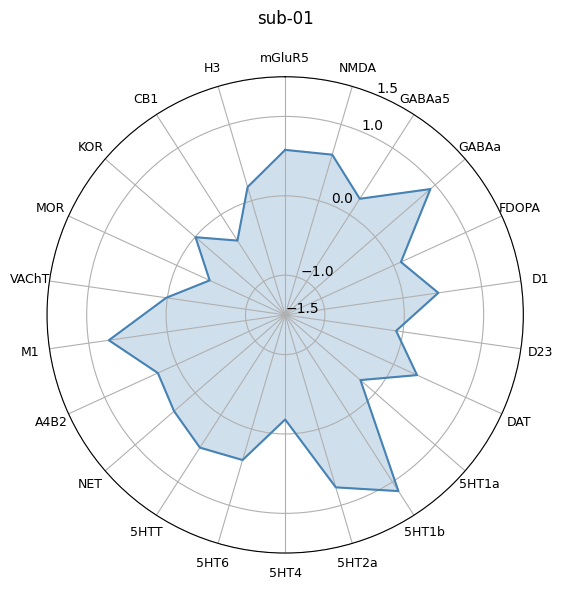

In [13]:
import numpy as np
import matplotlib.pyplot as plt

targets = df["target"].tolist()
values = df["value"].to_numpy()
angles = np.linspace(0, 2 * np.pi, len(targets), endpoint=False)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection="polar"))
ax.plot(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", linewidth=1.5)
ax.fill(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(targets, fontsize=9)
ax.set_ylim(-1.5, 1.5)
ax.set_yticks([-1.5, -1, 0, 1, 1.5])
ax.set_title("sub-01", pad=20)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
plt.tight_layout()
plt.show()


## Top neurotransmitter target overlaid on the lesion

Identify the highest-scoring target for sub-01 and plot the corresponding (z-scored) NT map with the lesion outline overlaid. The display is centred on the lesion centroid.

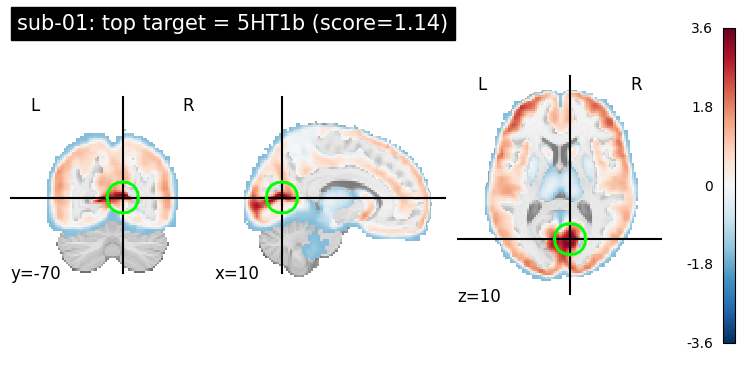

In [14]:
import nibabel as nib
import numpy as np
from nilearn import plotting
from pathlib import Path

scores = dict(zip(df["target"], df["value"]))
top_target = max(scores, key=scores.get)
nt_map = nib.load(Path("/tmp/ntatlas_data/maps") / f"{top_target}.nii.gz")
lesion_path = next(Path("/tmp/tutorial_bids/sub-01/ses-01/anat").glob("*mask*.nii.gz"))
lesion = nib.load(lesion_path)

coords = np.argwhere(lesion.get_fdata() > 0)
centroid_mm = (
    tuple(nib.affines.apply_affine(lesion.affine, coords.mean(axis=0)))
    if len(coords) else (0, 0, 0)
)

display = plotting.plot_stat_map(
    nt_map,
    display_mode="ortho",
    cut_coords=centroid_mm,
    title=f"sub-01: top target = {top_target} (score={scores[top_target]:.2f})",
    colorbar=True,
)
display.add_contours(str(lesion_path), levels=[0.5], colors="lime", linewidths=2)
plotting.show()


## ACE-enriched mode

LNTF can also score against an ACE-enriched (Atlas Connectivity Enrichment) atlas, where each NT map is augmented with connectivity information from a normative fMRI dataset. ACE preparation runs a per-subject GLM on the connectome's resting-state BOLD; LNTF then scores the lesion against the enriched maps the same way it scores the static atlas.

ACE preparation is expensive (~ minutes per subject) — do it once per (atlas, connectome) pair.

In [15]:
# Fetch a normative functional connectome for ACE (test mode = 10 subjects)
!lacuna fetch gsp1000 \
    --output-dir /tmp/gsp1000_data \
    --api-key $DATAVERSE_API_KEY \
    --test-mode \
    --skip-checksum \
    --no-keep-original

Fetching GSP1000 functional connectome...
  Mode: TEST (1 tarball only)


✓ GSP1000 fetch complete!
  Files: 2
  Duration: 0.0s
  Output: /tmp/gsp1000_data/processed


In [ ]:
# Prepare the ACE cache (subjects are streamed, so RAM stays bounded)
!lacuna prepare ace \
    --ntatlas-dir /tmp/ntatlas_data \
    --connectome-path /tmp/gsp1000_data/processed \
    --cache-dir /tmp/ace_cache \
    --max-subjects 10

In [17]:
# Run LNTF in enriched mode by swapping --ntatlas-dir for --ace-dir
!lacuna run lntf \
    /tmp/tutorial_bids/ \
    /tmp/outputs_lntf_ace/ \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --ace-dir /tmp/ace_cache

## Static vs ACE-enriched comparison

Static and ACE-enriched scores live on different scales (raw NT density vs Fisher-z mean), so the comparison z-scores each fingerprint within itself. The shape of the radar is what matters — which targets stand out — not the absolute radius.

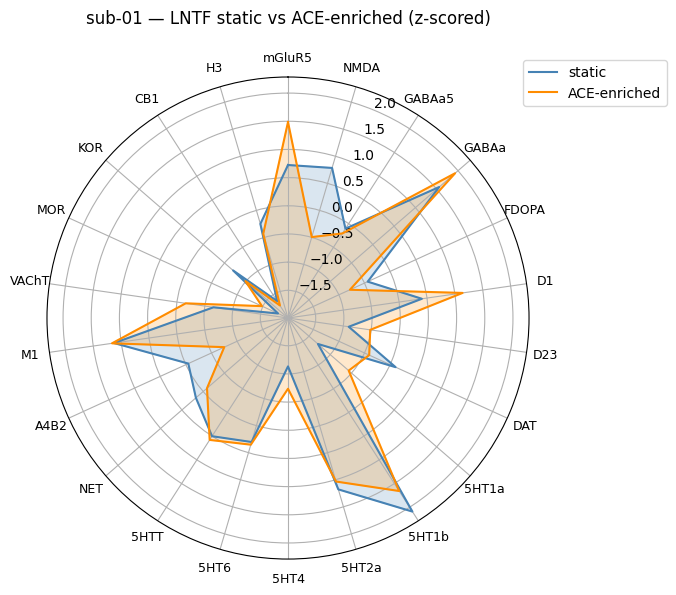

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tsv_static = next(Path('/tmp/outputs_lntf/sub-01/ses-01/anat').glob('*lntf*profilestats.tsv'))
tsv_ace = next(Path('/tmp/outputs_lntf_ace/sub-01/ses-01/anat').glob('*lntf*profilestats.tsv'))
df_static = pd.read_csv(tsv_static, sep='\t')
df_ace = pd.read_csv(tsv_ace, sep='\t')

targets = df_static['target'].tolist()

def zscore(v):
    v = np.asarray(v, dtype=float)
    sd = v.std()
    return (v - v.mean()) / (sd if sd > 0 else 1.0)

v_static = zscore(df_static.set_index('target').loc[targets, 'value'].to_numpy())
v_ace = zscore(df_ace.set_index('target').loc[targets, 'value'].to_numpy())

angles = np.linspace(0, 2 * np.pi, len(targets), endpoint=False)
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='polar'))
for v, label, color in [(v_static, 'static', 'steelblue'), (v_ace, 'ACE-enriched', 'darkorange')]:
    ax.plot(np.append(angles, angles[0]), np.append(v, v[0]),
            color=color, linewidth=1.5, label=label)
    ax.fill(np.append(angles, angles[0]), np.append(v, v[0]),
            color=color, alpha=0.2)
ax.set_xticks(angles)
ax.set_xticklabels(targets, fontsize=9)
ax.set_title('sub-01 — LNTF static vs ACE-enriched (z-scored)', pad=20)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05))
plt.tight_layout()
plt.show()